# Análise Arquiteturas Timeloop

In [9]:
import csv

with open('dse_pe_mac_width/dse_results.csv', mode='r', newline='') as csvfile:
    # Create a reader object (default delimiter is comma)
    #csv_reader = csv.reader(csvfile)
    csv_reader = csv.DictReader(csvfile)
    
    # Optional: Skip the header row if present
    # next(csv_reader, None) 
    
    # Iterate over each row
    for row in csv_reader:
        print(row)
            


{'arquitecture;percent_utilization;computes;cycles;cycle_seconds;latency;area;energy;computes_per_second;computes_per_second_per_square_meter;computes_per_joule;acesses;per_component_energy;per_component_area;variables': "1_neurons_2_macs_4_width;100.0;4480;2240;1e-09;2.24e-06;8.6297618e-08;1.7190521599999998e-08;2000000000.0;2.3175610710367464e+16;260608729871.23325;;{'MACC': 1.0051775999999999e-09", None: [" 'Input_Port': 2.08768e-11", " 'GlobalBuffer': 1.61644672e-08", " 'inter_MACC_spatial': 0};{'GlobalBuffer': 8.60227e-08", " 'Input_Port': 5.980000000000001e-12", " 'inter_MACC_spatial': 1e-12", " 'MACC': 2.67938e-10};Specification[variables].Variables={'version': '0.4'}"]}
{'arquitecture;percent_utilization;computes;cycles;cycle_seconds;latency;area;energy;computes_per_second;computes_per_second_per_square_meter;computes_per_joule;acesses;per_component_energy;per_component_area;variables': "1_neurons_2_macs_6_width;100.0;4480;2240;1e-09;2.24e-06;1.2959171399999998e-07;2.27114496e-

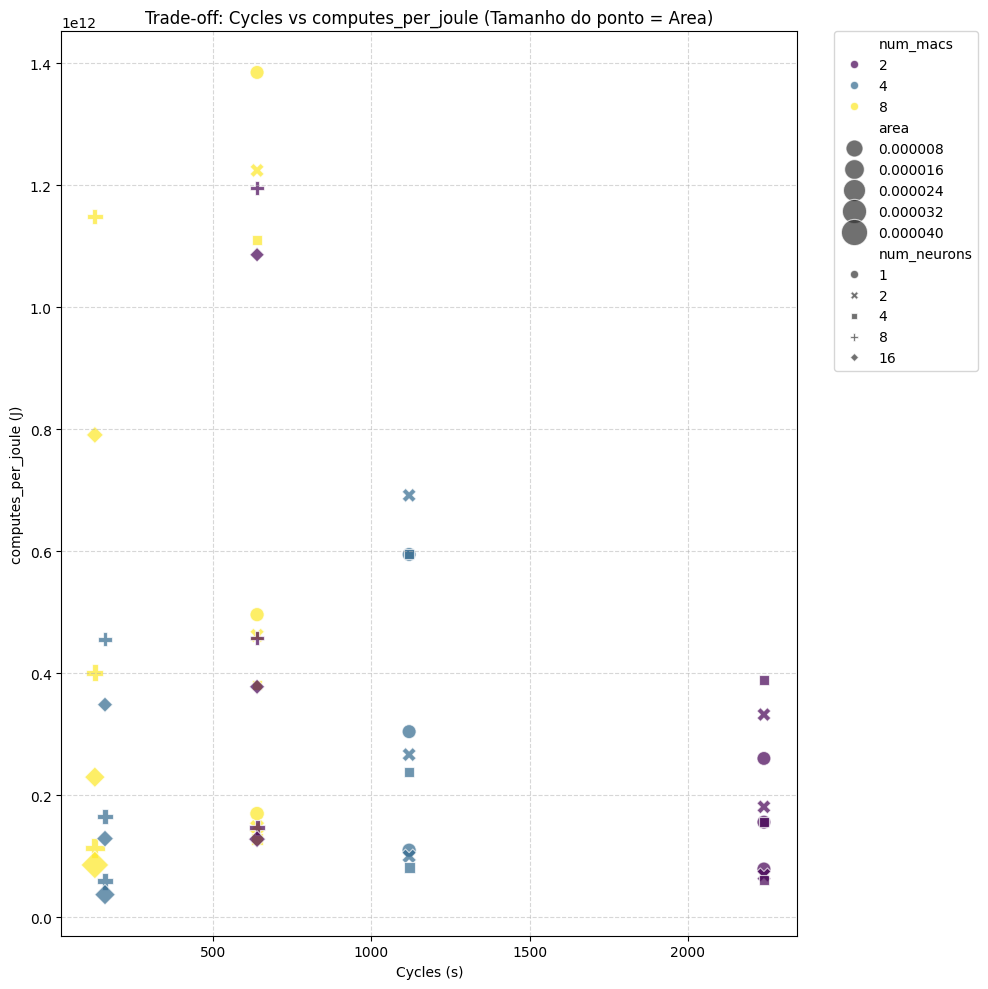

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados corretamente
file_path = 'dse_pe_mac_width/dse_results.csv'
try:
    df = pd.read_csv(file_path, sep=';', engine='python', on_bad_lines='skip')
except:
    print("Erro na leitura. Verifique o caminho do arquivo.")

# 2. Converter colunas para numérico (incluindo 'area')
cols_to_convert = ['cycles', 'computes_per_joule', 'area']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

    
df['num_macs'] = df['arquitecture'].str.split('_').str[2].astype(int)
df['num_neurons'] = df['arquitecture'].str.split('_').str[0].astype(int)

# 3. Criar o Gráfico
plt.figure(figsize=(10, 10))

sns.scatterplot(
    data=df, 
    x='cycles', 
    y='computes_per_joule', 
    hue='num_macs',   # Cores diferentes para cada arquitetura
    style='num_neurons', # Símbolos diferentes (ajuda se tiver muitas cores parecidas)
    size='area',          # <--- AQUI: Define o tamanho baseado na coluna 'area'
    sizes=(100, 400),      # (Min, Max): O menor ponto terá tamanho 50, o maior 400
    alpha=0.7,            # Transparência para ver pontos sobrepostos
    palette='viridis'     # Uma paleta de cores agradável
    
)


plt.title('Trade-off: Cycles vs computes_per_joule (Tamanho do ponto = Area)')
plt.xlabel('Cycles (s)')
plt.ylabel('computes_per_joule (J)')

# Move a legenda para fora para não cobrir os dados
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()